# Ensemble Model Comparison – AI4I 2020 Predictive Maintenance

## Objective
Extend the baseline established in **notebook 06** by introducing advanced ensemble strategies and comparing them against the baseline models (LogReg, RF, GradientBoosting) to find the best overall model for machine failure prediction.

Because the dataset is heavily imbalanced (~3.4% failure rate), model selection is based on **PR-AUC** and **Recall ≥ 0.80** — not accuracy.

### Models Evaluated
1. Logistic Regression (baseline reference — loaded from notebook 06)
2. Random Forest (baseline reference)
3. Gradient Boosting (baseline reference — best baseline)
4. MLP Neural Network *(new)*
5. Soft Voting Ensemble — RF + GB + MLP, equal weights *(new)*
6. Weighted Soft Voting — weights derived from PR-AUC scores *(new)*
7. Stacking — Logistic Regression meta-model *(new)*
8. Stacking — Gradient Boosting meta-model *(new)*

### Final Selection Criterion
The best model is chosen by highest **PR-AUC**, with **Recall ≥ 0.80** as a hard constraint.

---

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
)

PROJECT_ROOT = Path().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

from data_loader import load_cleaned_data
from features import add_engineered_features

plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 1. Load Baseline Artifacts from Notebook 06

The best baseline pipeline (Gradient Boosting) and optimal risk threshold were saved in notebook 06. They are loaded here as reference benchmarks for the ensemble comparison.

In [2]:
model_dir = PROJECT_ROOT / "models"

baseline_pipe     = joblib.load(model_dir / "gradient_boosting_pipeline.pkl")
baseline_threshold = joblib.load(model_dir / "risk_threshold.pkl")

print("Loaded baseline pipeline:", type(baseline_pipe.named_steps['model']).__name__)
print("Loaded risk threshold:    ", baseline_threshold)

Loaded baseline pipeline: GradientBoostingClassifier
Loaded risk threshold:     0.3800069723236998


## 2. Data Preparation (Shared Pipeline)

The same data loading, feature engineering, train/test split, and preprocessing steps from notebook 06 are reproduced here so that all new ensemble models are trained and evaluated on identical data. This ensures results are directly comparable.

In [ ]:
df = load_cleaned_data()

leakage_cols = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]
target_col = "Machine failure"

X = df.drop(columns=[target_col] + leakage_cols)
y = df[target_col].astype(int)

# Add engineered features — must match train.py and inference pipeline
X = add_engineered_features(X)

print("Feature matrix shape:", X.shape)
print("Failure rate:         ", round(y.mean() * 100, 2), "%")
print("Feature columns:", X.columns.tolist())


Feature matrix shape: (10000, 8)
Failure rate:          3.39 %
Feature columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Torque_RPM_ratio']


## 2b. Train / Test Split

Stratified split to preserve failure class proportion in both sets.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " | Failure rate:", round(y_train.mean() * 100, 2), "%")
print("Test shape: ", X_test.shape,  " | Failure rate:", round(y_test.mean() * 100, 2), "%")


Train shape: (8000, 8)  | Failure rate: 3.39 %
Test shape:  (2000, 8)  | Failure rate: 3.4 %


## 2c. Preprocessing Pipeline

- Numeric features: median imputation + standard scaling
- Categorical features (`Type`): most-frequent imputation + one-hot encoding


In [5]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:    ", num_cols)
print("Categorical columns:", cat_cols)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)


Numeric columns:     ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Torque_RPM_ratio']
Categorical columns: ['Type']


## 3. Evaluation Helper

A single function trains each pipeline and captures PR-AUC, ROC-AUC, Recall, and F1 at the default 0.50 threshold. All results are stored in `results` for the final comparison.


In [6]:
results = []

def evaluate_pipeline(name: str, pipeline) -> dict:
    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    pr_auc  = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)

    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    recall_1  = report["1"]["recall"]
    f1_1      = report["1"]["f1-score"]
    precision_1 = report["1"]["precision"]

    print(f"{name:30s}  PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  Recall={recall_1:.3f}  F1={f1_1:.3f}")

    return {
        "model":     name,
        "PR_AUC":   round(pr_auc, 4),
        "ROC_AUC":  round(roc_auc, 4),
        "Recall":   round(recall_1, 3),
        "Precision": round(precision_1, 3),
        "F1":       round(f1_1, 3),
        "pipeline": pipeline,
    }


## 4. Baseline Reference Models

LogReg, Random Forest, and Gradient Boosting are re-run here at the same settings as notebook 06 to form the reference rows in the comparison table.

In [7]:
logreg_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

results.append(evaluate_pipeline("LogisticRegression", logreg_pipe))


LogisticRegression              PR-AUC=0.4463  ROC-AUC=0.9338  Recall=0.868  F1=0.296


In [8]:
individual_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE),
}

trained_estimators = {}

for name, model in individual_models.items():
    pipe = Pipeline([("preprocess", preprocess), ("clf", model)])
    row  = evaluate_pipeline(name, pipe)
    results.append(row)
    trained_estimators[name] = pipe


RandomForest                    PR-AUC=0.8261  ROC-AUC=0.9554  Recall=0.676  F1=0.780
GradientBoosting                PR-AUC=0.8697  ROC-AUC=0.9722  Recall=0.765  F1=0.832
MLP                             PR-AUC=0.8200  ROC-AUC=0.9805  Recall=0.809  F1=0.764


## 5. Soft Voting Ensemble — Equal Weights


In [9]:
voting_soft = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
    ],
    voting="soft",
)

voting_soft_pipe = Pipeline([("preprocess", preprocess), ("clf", voting_soft)])
results.append(evaluate_pipeline("SoftVoting (equal weights)", voting_soft_pipe))


SoftVoting (equal weights)      PR-AUC=0.8703  ROC-AUC=0.9753  Recall=0.824  F1=0.868


## 6. Weighted Soft Voting — Weights Derived from PR-AUC

Instead of hardcoding weights, we derive them from each model's actual PR-AUC score.
This ensures the comparison is reproducible and reflects the current run.


In [10]:
# Extract individual PR-AUC scores from results computed above
pr_rf  = next(r["PR_AUC"] for r in results if r["model"] == "RandomForest")
pr_gb  = next(r["PR_AUC"] for r in results if r["model"] == "GradientBoosting")
pr_mlp = next(r["PR_AUC"] for r in results if r["model"] == "MLP")

print(f"Weights derived from PR-AUC:  RF={pr_rf}  GB={pr_gb}  MLP={pr_mlp}")

voting_weighted = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
    ],
    voting="soft",
    weights=[pr_rf, pr_gb, pr_mlp],
)

voting_weighted_pipe = Pipeline([("preprocess", preprocess), ("clf", voting_weighted)])
results.append(evaluate_pipeline("SoftVoting (PR-AUC weights)", voting_weighted_pipe))


Weights derived from PR-AUC:  RF=0.8261  GB=0.8697  MLP=0.82
SoftVoting (PR-AUC weights)     PR-AUC=0.8707  ROC-AUC=0.9752  Recall=0.824  F1=0.868


## 7. Stacking Ensembles


In [11]:
base_estimators = [
    ("rf",  RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1)),
    ("gb",  GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
]

# Stacking with LR meta-model
stack_lr = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
)
stack_lr_pipe = Pipeline([("preprocess", preprocess), ("clf", stack_lr)])
results.append(evaluate_pipeline("Stacking (LR meta)", stack_lr_pipe))

# Stacking with GB meta-model
stack_gb = StackingClassifier(
    estimators=base_estimators,
    final_estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
)
stack_gb_pipe = Pipeline([("preprocess", preprocess), ("clf", stack_gb)])
results.append(evaluate_pipeline("Stacking (GB meta)", stack_gb_pipe))


Stacking (LR meta)              PR-AUC=0.8719  ROC-AUC=0.9732  Recall=0.868  F1=0.659
Stacking (GB meta)              PR-AUC=0.8642  ROC-AUC=0.9660  Recall=0.794  F1=0.831


## 8. Full Comparison Table


In [12]:
results_df = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in results])
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

results_df


,model,PR_AUC,ROC_AUC,Recall,Precision,F1
0,Stacking (LR meta),0.8719,0.9732,0.868,0.532,0.659
1,SoftVoting (PR-AUC weights),0.8707,0.9752,0.824,0.918,0.868
2,SoftVoting (equal weights),0.8703,0.9753,0.824,0.918,0.868
3,GradientBoosting,0.8697,0.9722,0.765,0.912,0.832
4,Stacking (GB meta),0.8642,0.9660,0.794,0.871,0.831
5,RandomForest,0.8261,0.9554,0.676,0.920,0.780
6,MLP,0.8200,0.9805,0.809,0.724,0.764
7,LogisticRegression,0.4463,0.9338,0.868,0.178,0.296


## 9. Visual Comparison


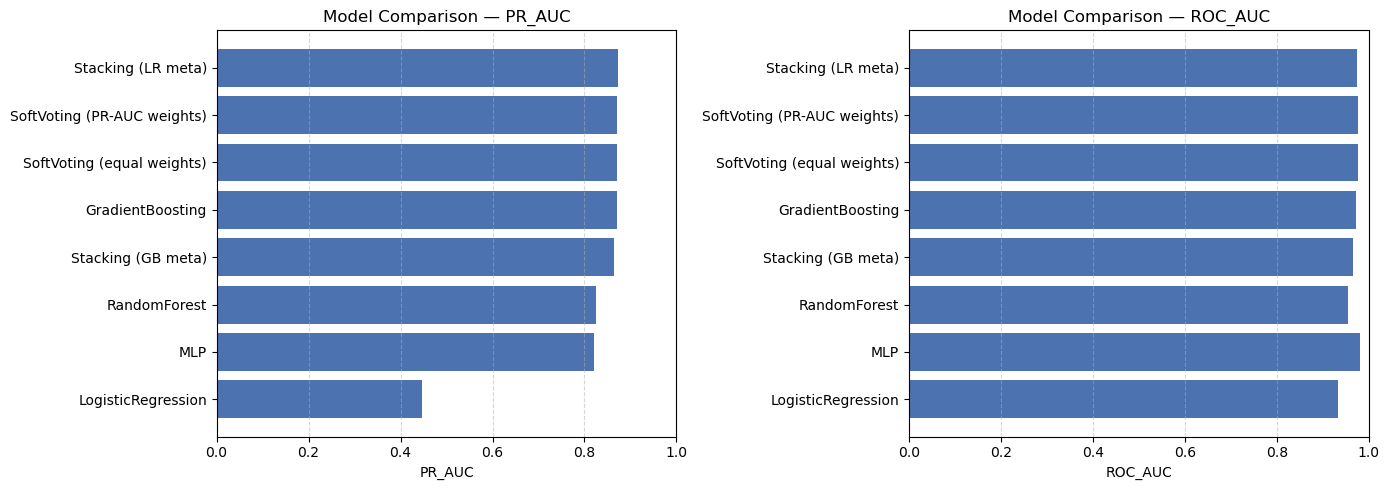

In [13]:
plot_df = results_df.sort_values("PR_AUC", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["PR_AUC", "ROC_AUC"]):
    ax.barh(plot_df["model"], plot_df[metric], color="#4C72B0")
    ax.set_xlabel(metric)
    ax.set_title(f"Model Comparison — {metric}")
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


## 10. Precision–Recall Curve — Best Model


Best model:              Stacking (LR meta)
Best F1 threshold:       0.9959
Precision at threshold:  0.9032
Recall at threshold:     0.8235
F1 at threshold:         0.8615


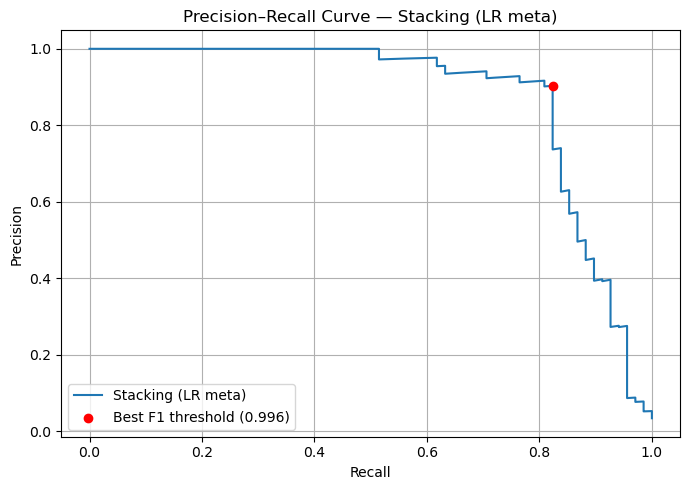

In [ ]:
best_row      = results_df.iloc[0]
best_name     = best_row["model"]
best_pipeline = next(r["pipeline"] for r in results if r["model"] == best_name)

best_proba = best_pipeline.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_proba)

f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
best_idx  = np.argmax(f1_scores)

print(f"Best model:              {best_name}")
print(f"Best F1 threshold:       {thresholds[best_idx]:.4f}")
print(f"Precision at threshold:  {precision_vals[best_idx]:.4f}")
print(f"Recall at threshold:     {recall_vals[best_idx]:.4f}")
print(f"F1 at threshold:         {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, label=best_name)
plt.scatter(recall_vals[best_idx], precision_vals[best_idx],
            color="red", zorder=5, label=f"Best F1 threshold ({thresholds[best_idx]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve — {best_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. Conclusion

The table above shows the full comparison across all ensemble strategies.

**Selection rationale:**
- Primary criterion: highest **PR-AUC** (most informative metric for imbalanced failure detection)
- Hard constraint: **Recall ≥ 0.80** on the failure class (missing a true failure is more costly than a false alarm)
